In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mlflow
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix,
)
from mlflow.models.signature import infer_signature
from mlflow.tracking import MlflowClient
import warnings
import time

warnings.filterwarnings('ignore')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
data = pd.read_csv("/Users/pratham/code/MLops/Labs/MLOps-Labs/Lab 3 - MLflow/data/train.csv")

print("Dataset Shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())
print("\nData Types:")
print(data.dtypes)
print("\nBasic Statistics:")
print(data.describe())

Dataset Shape: (165034, 14)

First 5 rows:
   id  CustomerId         Surname  CreditScore Geography Gender   Age  Tenure  \
0   0    15674932  Okwudilichukwu          668    France   Male  33.0       3   
1   1    15749177   Okwudiliolisa          627    France   Male  33.0       1   
2   2    15694510           Hsueh          678    France   Male  40.0      10   
3   3    15741417             Kao          581    France   Male  34.0       2   
4   4    15766172       Chiemenam          716     Spain   Male  33.0       5   

     Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0       0.00              2        1.0             0.0        181449.97   
1       0.00              2        1.0             1.0         49503.50   
2       0.00              2        1.0             0.0        184866.69   
3  148882.54              1        1.0             1.0         84560.88   
4       0.00              2        1.0             1.0         15068.83   

   Exited  
0      

In [5]:
data.drop(columns=["id", "CustomerId", "Surname"], inplace=True)
print("\nColumns after dropping irrelevant features:")
print(data.columns.tolist())



Columns after dropping irrelevant features:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [6]:
print("\nMissing values per column:")
print(data.isnull().sum())



Missing values per column:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [7]:
data["HasCrCard"].fillna(data["HasCrCard"].mode()[0], inplace=True)
data["IsActiveMember"].fillna(data["IsActiveMember"].mode()[0], inplace=True)
data["Age"].fillna(data["Age"].median(), inplace=True)

In [8]:

data["HasCrCard"] = data["HasCrCard"].astype(int)
data["IsActiveMember"] = data["IsActiveMember"].astype(int)

In [9]:
label_encoders = {}
for col in ["Geography", "Gender"]:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le
    print(f"\n{col} encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nPreprocessed data shape:", data.shape)
print(data.head())


Geography encoding: {'France': np.int64(0), 'Germany': np.int64(1), 'Spain': np.int64(2)}

Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}

Preprocessed data shape: (165034, 11)
   CreditScore  Geography  Gender   Age  Tenure    Balance  NumOfProducts  \
0          668          0       1  33.0       3       0.00              2   
1          627          0       1  33.0       1       0.00              2   
2          678          0       1  40.0      10       0.00              2   
3          581          0       1  34.0       2  148882.54              1   
4          716          2       1  33.0       5       0.00              2   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               0        181449.97       0  
1          1               1         49503.50       0  
2          1               0        184866.69       0  
3          1               1         84560.88       0  
4          1               1         15068.83       0  


In [10]:
print("\nTarget Distribution:")
print(data["Exited"].value_counts())
print(f"\nChurn Rate: {data['Exited'].mean() * 100:.2f}%")


Target Distribution:
Exited
0    130113
1     34921
Name: count, dtype: int64

Churn Rate: 21.16%


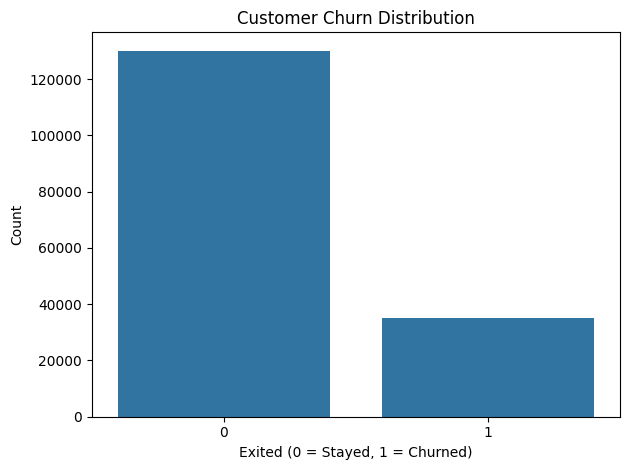

In [11]:
sns.countplot(x="Exited", data=data)
plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("churn_distribution.png")
plt.show()

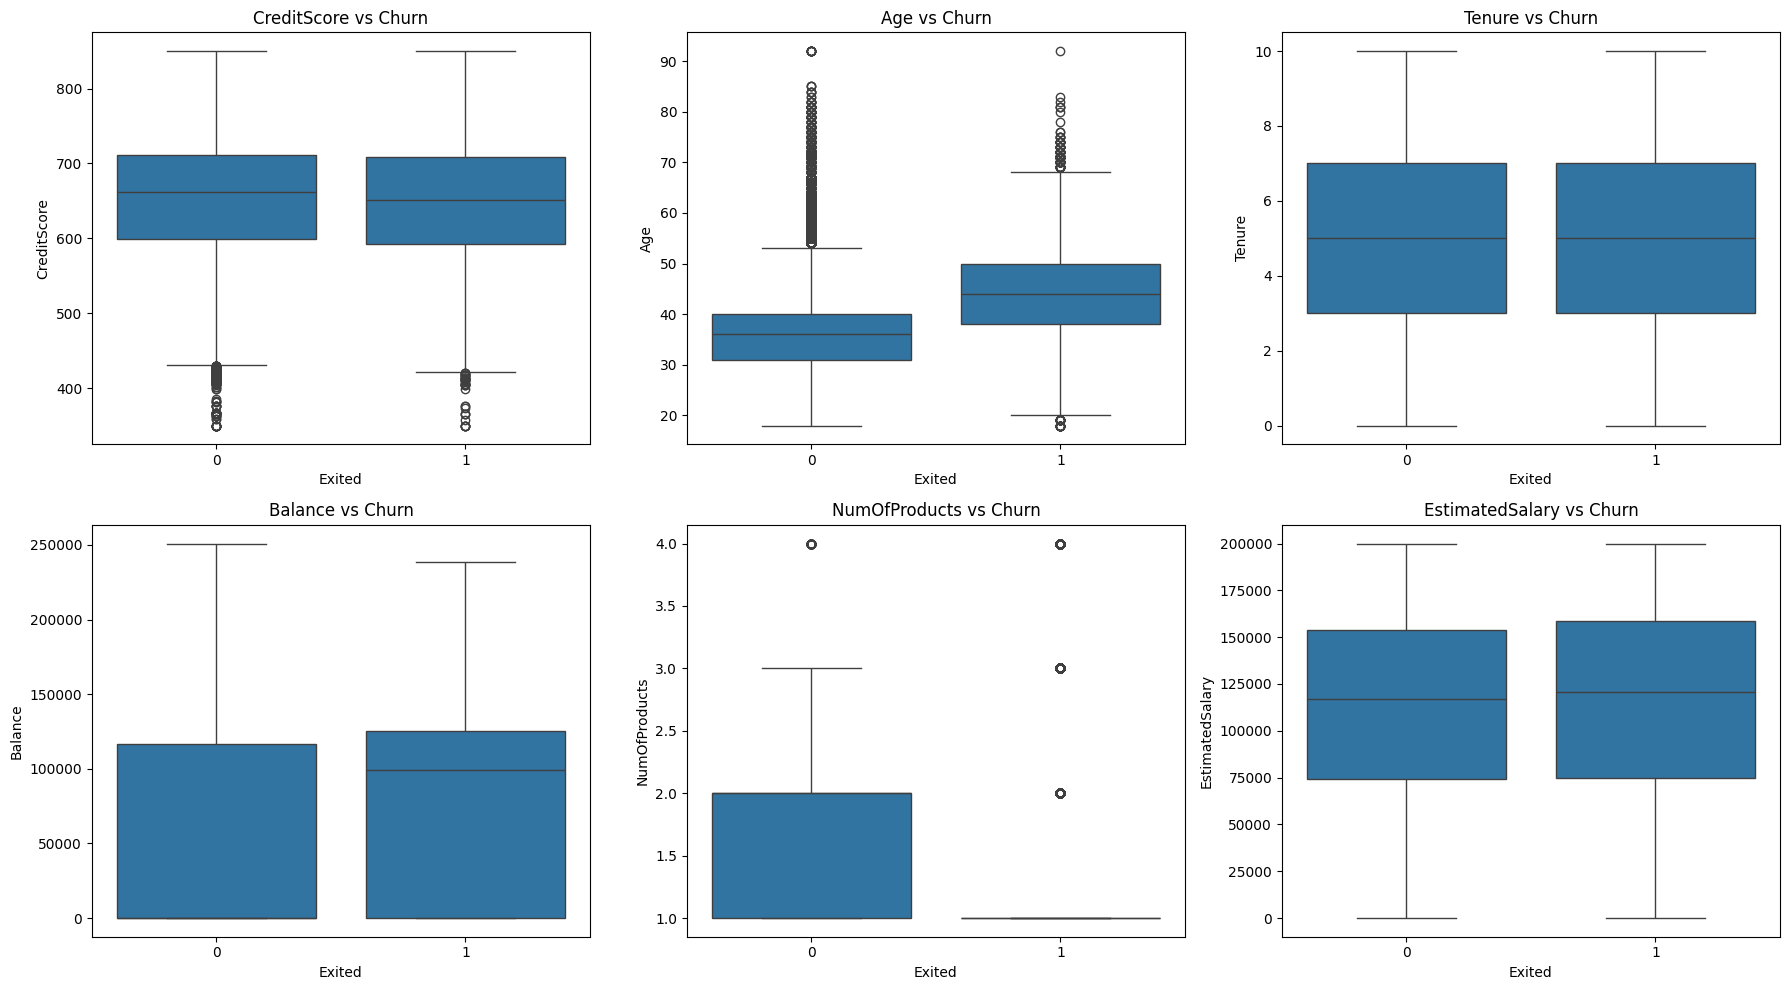

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(numerical_cols):
    row, col_idx = i // 3, i % 3
    sns.boxplot(x="Exited", y=col, data=data, ax=axes[row][col_idx])
    axes[row][col_idx].set_title(f"{col} vs Churn")
plt.tight_layout()
plt.savefig("feature_boxplots.png")
plt.show()

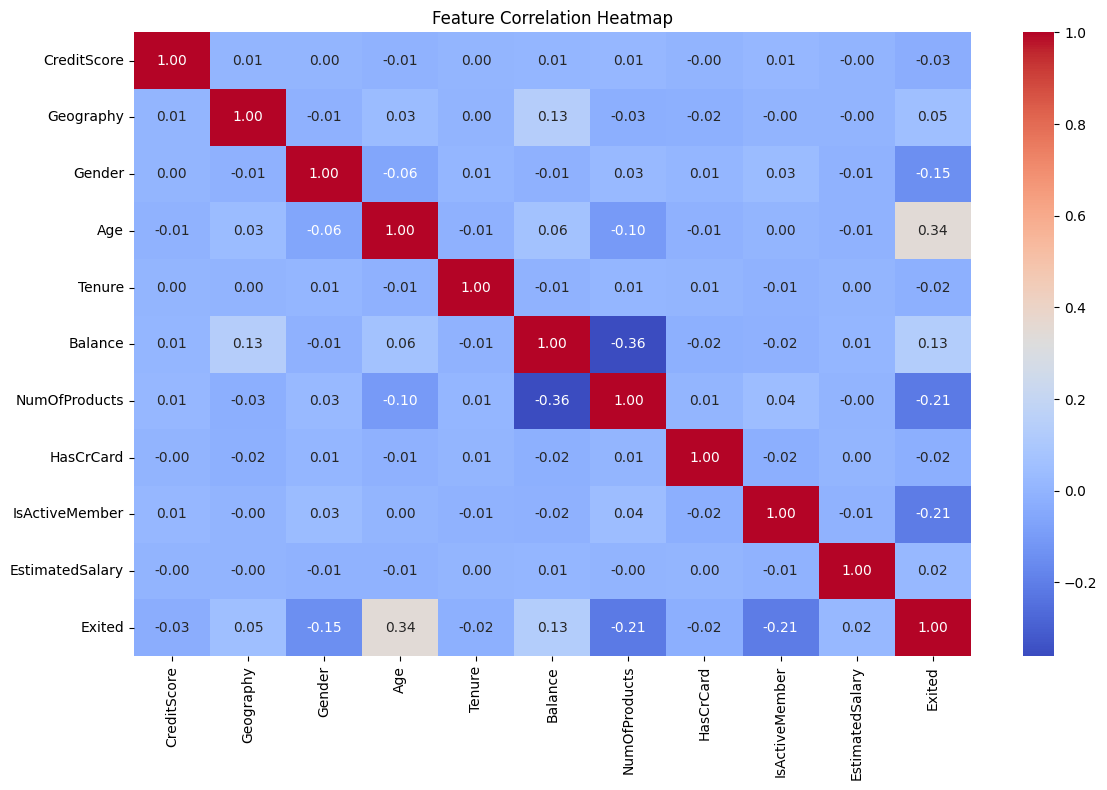

In [14]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

In [16]:
X = data.drop("Exited", axis=1)
y = data["Exited"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

Training set:   132027 samples
Validation set: 33007 samples


In [18]:
def train_and_log_model(model, model_name, X_train, y_train, X_val, y_val, params):
    """
    Trains a model, logs params/metrics/artifacts to MLflow,
    and returns the run ID and validation AUC.
    """
    with mlflow.start_run(run_name=model_name) as run:
        # Train
        model.fit(X_train, y_train)

        # Predict on validation set
        val_predictions = model.predict(X_val)
        val_proba = model.predict_proba(X_val)[:, 1]

        # Calculate metrics
        val_auc = roc_auc_score(y_val, val_proba)
        val_accuracy = accuracy_score(y_val, val_predictions)
        val_f1 = f1_score(y_val, val_predictions)
        val_precision = precision_score(y_val, val_predictions)
        val_recall = recall_score(y_val, val_predictions)

        # Log parameters
        for param_name, param_value in params.items():
            mlflow.log_param(param_name, param_value)

        # Log metrics
        mlflow.log_metric("val_auc", val_auc)
        mlflow.log_metric("val_accuracy", val_accuracy)
        mlflow.log_metric("val_f1", val_f1)
        mlflow.log_metric("val_precision", val_precision)
        mlflow.log_metric("val_recall", val_recall)

        # Log confusion matrix as artifact
        cm = confusion_matrix(y_val, val_predictions)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Stayed", "Churned"],
                    yticklabels=["Stayed", "Churned"])
        plt.title(f"Confusion Matrix - {model_name}")
        plt.ylabel("Actual")
        plt.xlabel("Predicted")
        plt.tight_layout()
        cm_path = f"confusion_matrix_{model_name}.png"
        plt.savefig(cm_path)
        mlflow.log_artifact(cm_path)
        plt.show()

        # Log the model
        signature = infer_signature(X_train, model.predict_proba(X_train)[:, 1])
        mlflow.sklearn.log_model(model, model_name, signature=signature)

        print(f"\n{'='*50}")
        print(f"Model: {model_name}")
        print(f"{'='*50}")
        print(f"  AUC:       {val_auc:.4f}")
        print(f"  Accuracy:  {val_accuracy:.4f}")
        print(f"  F1 Score:  {val_f1:.4f}")
        print(f"  Precision: {val_precision:.4f}")
        print(f"  Recall:    {val_recall:.4f}")

        return run.info.run_id, val_auc


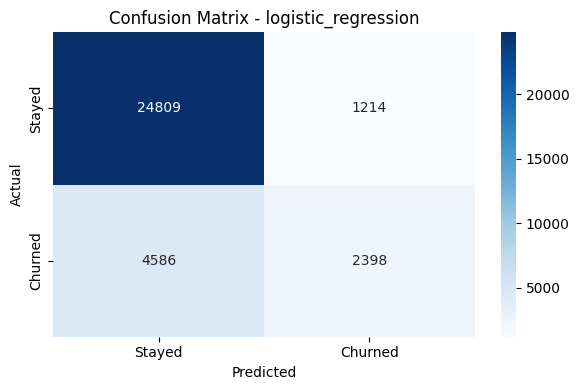

2026/03/01 20:28:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 20:28:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Model: logistic_regression
  AUC:       0.8000
  Accuracy:  0.8243
  F1 Score:  0.4526
  Precision: 0.6639
  Recall:    0.3434


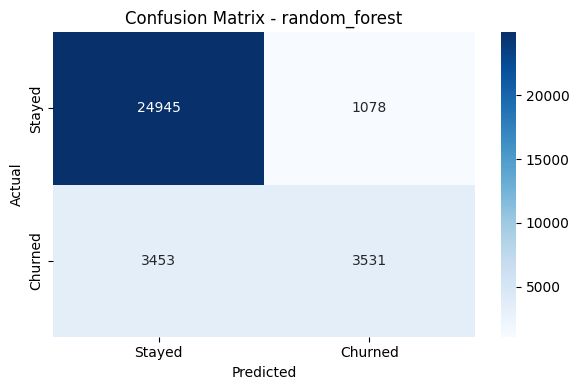

2026/03/01 20:28:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 20:28:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Model: random_forest
  AUC:       0.8874
  Accuracy:  0.8627
  F1 Score:  0.6092
  Precision: 0.7661
  Recall:    0.5056


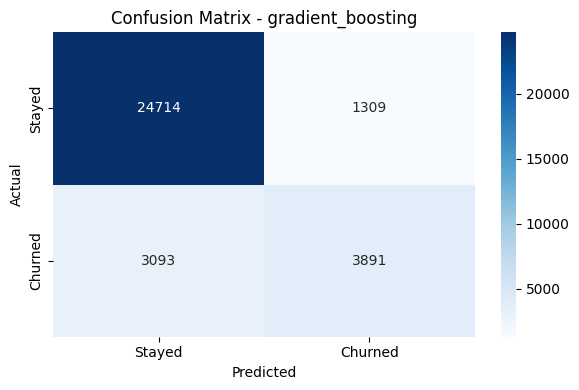

2026/03/01 20:29:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 20:29:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Model: gradient_boosting
  AUC:       0.8899
  Accuracy:  0.8666
  F1 Score:  0.6387
  Precision: 0.7483
  Recall:    0.5571


In [37]:
results = {}

# --- Model 1: Logistic Regression ---
lr_params = {"C": 1.0, "max_iter": 1000, "solver": "lbfgs"}
lr_model = LogisticRegression(**lr_params, random_state=42)
lr_run_id, lr_auc = train_and_log_model(
    lr_model, "logistic_regression",
    X_train, y_train, X_val, y_val, lr_params
)
results["logistic_regression"] = {"run_id": lr_run_id, "auc": lr_auc}

# --- Model 2: Random Forest ---
rf_params = {"n_estimators": 200, "max_depth": 10, "min_samples_split": 5}
rf_model = RandomForestClassifier(**rf_params, random_state=42)
rf_run_id, rf_auc = train_and_log_model(
    rf_model, "random_forest",
    X_train, y_train, X_val, y_val, rf_params
)
results["random_forest"] = {"run_id": rf_run_id, "auc": rf_auc}

# --- Model 3: Gradient Boosting ---
gb_params = {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.1}
gb_model = GradientBoostingClassifier(**gb_params, random_state=42)
gb_run_id, gb_auc = train_and_log_model(
    gb_model, "gradient_boosting",
    X_train, y_train, X_val, y_val, gb_params
)
results["gradient_boosting"] = {"run_id": gb_run_id, "auc": gb_auc}


In [38]:
print("\n" + "=" * 60)
print("MODEL COMPARISON (Validation AUC)")
print("=" * 60)
for model_name, info in sorted(results.items(), key=lambda x: x[1]["auc"], reverse=True):
    print(f"  {model_name:25s} AUC: {info['auc']:.4f}")

# Identify the best model
best_model_name = max(results, key=lambda x: results[x]["auc"])
best_run_id = results[best_model_name]["run_id"]
best_auc = results[best_model_name]["auc"]
print(f"\nBest Model: {best_model_name} (AUC: {best_auc:.4f})")


MODEL COMPARISON (Validation AUC)
  gradient_boosting         AUC: 0.8899
  random_forest             AUC: 0.8874
  logistic_regression       AUC: 0.8000

Best Model: gradient_boosting (AUC: 0.8899)


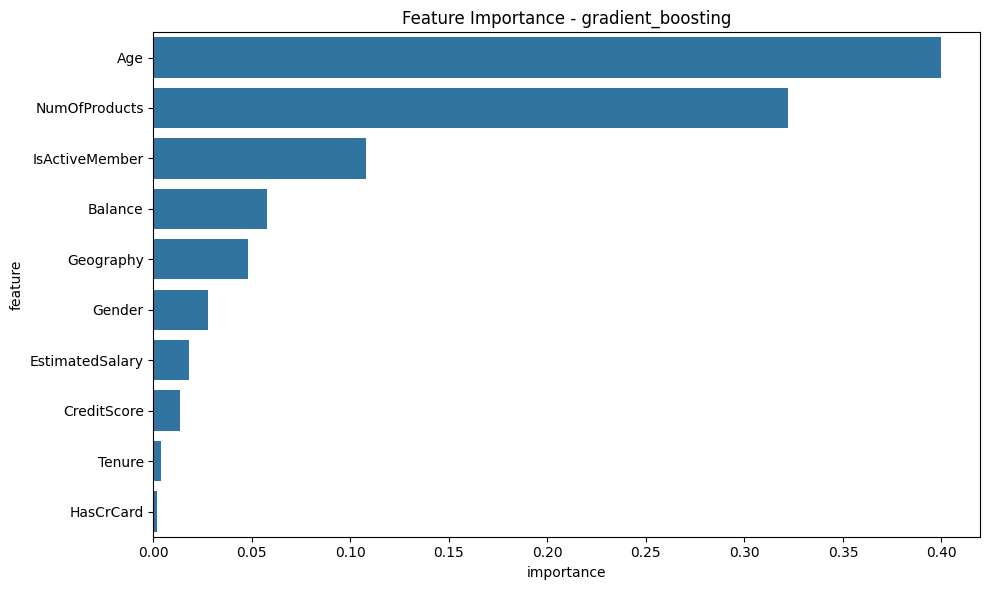


Feature Importances:
        feature  importance
            Age    0.399591
  NumOfProducts    0.321968
 IsActiveMember    0.107722
        Balance    0.057813
      Geography    0.047779
         Gender    0.027957
EstimatedSalary    0.017901
    CreditScore    0.013523
         Tenure    0.003888
      HasCrCard    0.001859


In [40]:
if hasattr(loaded_model, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "feature": X_train.columns,
        "importance": loaded_model.feature_importances_
    }).sort_values("importance", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x="importance", y="feature", data=feature_importance)
    plt.title(f"Feature Importance - {best_model_name}")
    plt.tight_layout()
    plt.savefig("feature_importance.png")
    plt.show()

    print("\nFeature Importances:")
    print(feature_importance.to_string(index=False))

In [41]:
model_name_registry = "bank-churn-predictor"
model_version = mlflow.register_model(
    f"runs:/{best_run_id}/{best_model_name}",
    model_name_registry
)
print(f"\nRegistered model: {model_name_registry}, version: {model_version.version}")

time.sleep(15)

Successfully registered model 'bank-churn-predictor'.
2026/03/01 20:29:15 WARNING mlflow.tracking._model_registry.fluent: Run with id 79426109258d4ada84bab7a7db8a10ed has no artifacts at artifact path 'gradient_boosting', registering model based on models:/m-e3e413bb987f431db782287ad2d7b556 instead



Registered model: bank-churn-predictor, version: 1


Created version '1' of model 'bank-churn-predictor'.


In [42]:
client = MlflowClient()
client.transition_model_version_stage(
    name=model_name_registry,
    version=model_version.version,
    stage="Production"
)
print(f"Model version {model_version.version} transitioned to Production")


Model version 1 transitioned to Production


In [43]:
production_model = mlflow.pyfunc.load_model(
    f"models:/{model_name_registry}/production"
)
production_predictions = production_model.predict(X_test)
production_auc = roc_auc_score(y_test, production_predictions)
print(f"\nProduction Model AUC (sanity check): {production_auc:.4f}")


Production Model AUC (sanity check): 0.7592


In [45]:
print("To serve the model, run in terminal:")
print(f"mlflow models serve -m models:/{model_name_registry}/production -h 0.0.0.0 -p 5001")

To serve the model, run in terminal:
mlflow models serve -m models:/bank-churn-predictor/production -h 0.0.0.0 -p 5001


In [36]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("bank-churn-prediction")

2026/03/01 20:27:10 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/01 20:27:10 INFO mlflow.store.db.utils: Updating database tables
2026/03/01 20:27:10 INFO mlflow.tracking.fluent: Experiment with name 'bank-churn-prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Users/pratham/code/MLops/Labs/MLOps-Labs/Lab 3 - MLflow/src/mlruns/1', creation_time=1772414830750, experiment_id='1', last_update_time=1772414830750, lifecycle_stage='active', name='bank-churn-prediction', tags={}, workspace='default'>

In [47]:
import requests

url = 'http://localhost:5001/invocations'
sample = X_val.head(5)
data = {"dataframe_split": sample.to_dict(orient='split')}
response = requests.post(url, json=data)
print(response.json())

{'predictions': [0, 1, 0, 0, 0]}
